In [94]:
import pandas as pd
import numpy as np
import openpyxl as xl

In [95]:
# path = "../raw-data/SHPD consolidated.xlsx"
# det_df = pd.read_excel(path, sheet_name = "21-24 Det")

path = "../raw-data/shpd-plumb.csv"
det_df = pd.read_csv(path)

# print(det_df.describe())
# print(det_df["Opinion 6E"].unique())
# so there is no effect, effect with proposal, and effect with agreement

# adding in the labels that I did...
labels = pd.read_csv('../raw-data/labels.csv')
det_df = pd.merge(det_df, labels, how = "left", on = 'Project Name')
print(det_df.columns.to_list())

['Project Number', 'Project Name', 'Date Opinion 106', 'Opinion 106', 'Opinion 106 Comment', 'Date Opinion 6E', 'Opinion 6E', 'Opinion 6E Comment', 'Statutes', 'Agency', 'Island', 'Tax Map Keys', 'Label']


## Cleaning

We have to make some things right for the analysis.

1. need to create year variable using substring from permit id
2. need to standardize formats (use the clean part of the workbook?)

In [96]:
# smol, need to make NaN to strings in label column
det_df['Label'] = det_df['Label'].fillna("").astype(str) # converts NaNs to "" then safe .lower()

In [97]:
# cleaning up the dependent output variables

def classify_outcome(text: str) -> str:
    # if it does not exist
    if not isinstance(text, str):
        return None
    # forces to be lower case and without any spaces/newlines
    s = text.strip().lower()

    if "no" in s:
        return "no effect"
    elif "agreed" in s:
        return "effect with agreed commitments"
    elif "proposed" in s:
        return "effect with proposed commitments"
    else:
        return "NA"

def binary_outcome(text: str) -> str:
    if not isinstance(text, str):
        return None
    
    s = text.strip().lower() #lower just in case
    if "no" in s:
        return "no effect"
    if "effect" in s:
        return "effect"
    else:
        return "NA"


det_df["Opinion 6E"] = det_df["Opinion 6E"].apply(classify_outcome)
print(det_df["Opinion 6E"].unique())

det_df["opinion_6e_binary"] = det_df["Opinion 6E"].apply(binary_outcome)

<StringArray>
[                       'no effect',   'effect with agreed commitments',
 'effect with proposed commitments',                                nan]
Length: 4, dtype: str


In [98]:
# cleaning descriptions
from spellchecker import SpellChecker
import re

stopwords = {
    # Administrative / Process terms
    "permit", "permits", "permitting", "application", "applications", "project", "request", "existing", 
    "tmk", "job", "concurrence", "determination", "management", "department", 
    "state", "county", "coh", "smx", "cwrm", "gd", "id", "no", "name", 
    "statutes", "agency", "island", # "clearinghouse",
    
    # Common Connectors
    "for", "the", "and", "with", "from", "this", "that", "was", "were", "of"
    
    # # Numbers, Years, and Codes
    # "pw", "pweng", "eng",
    "2020", "2021", "2022", "2023", "a2021", "a2022", "a2023", "t2021", 
    "001", "phase", "1", "2", "3", "4", "5", "6", "7", "8", "9", "0", "por",
    
    # Location / Geographic Noise
    "maui", "honolulu", "hawaii", "oahu", "kauai", "lanai", "molokai",
    #"street", "st", "rd", "road", "highway",
    
    # Legal and Business Entities
    # "llc", "inc", "corp", "trust" #"owner", "family"
}

def clean(text, stopwords = stopwords):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # digits
    text = re.sub(r'[^a-z\s]', '', text)
    # return text
    #remove matches to stopwords
    pattern = r'\b(' + '|'.join(re.escape(word) for word in stopwords) + r')\b\s*'
    text = re.sub(pattern, '', text)
    return text #.strip()

# import spacy
# nlp = spacy.load("en_core_web_sm")

# i feel like this is unnecessary now...
# def clean_permit_text(text):
#     doc = nlp(str(text).lower())
#     # Keep only words that are NOT stopwords and are alphabetic
#     tokens = [token.lemma_ for token in doc if token.text not in stopwords and token.is_alpha]
#     return " ".join(tokens)


det_df["Project Name"] = det_df["Project Name"].apply(clean)
print(det_df["Label"].dtype)
det_df["Label"] = det_df["Label"].apply(clean)
# det_df['Clean_Name'] = det_df['Project Name'].apply(clean_permit_text)

# no need to do this? since we fixed the spelling mistakes
# spell = SpellChecker()

# def spellCheck(text: str) -> str:
#     if pd.isna(text):
#         return text
#     return " ".join(spell.correction(w) or w for w in text.split())

# det_df["Project Name"] = det_df["Project Name"].apply(spellCheck)


str


In [99]:
for name in det_df["Label"]:
    if "permit" in name:
        print(name)
det_df.head()

,Project Number,Project Name,Date Opinion 106,Opinion 106,Opinion 106 Comment,Date Opinion 6E,Opinion 6E,Opinion 6E Comment,Statutes,Agency,Island,Tax Map Keys,Label,opinion_6e_binary
0,2012PR00405,dpp matthew alicia willis fax grading access...,NaN,NaN,NaN,5/12/2021,no effect,NaN,HRS 6E-42,NaN,Oʻahu,(1) 4-5-047:040,site prep,no effect
1,2013PR04659,of sma use construction of a single family dwe...,NaN,NaN,NaN,6/16/2023,effect with agreed commitments,"SHPD hereby notifies the County of Hawaii, Dep...",HRS 6E-42,"County of Hawaii, Planning Department",Hawaiʻi,(3) 4-9-003:005,,effect
2,2014PR14733,dags nanakuli library,NaN,NaN,NaN,8/31/2023,no effect,NaN,HRS 6E-8,NaN,Oʻahu,189002065por.,,no effect
3,2015PR19955,clearinghouse cl princeville makai ranch road g h,NaN,NaN,NaN,8/31/2023,no effect,NaN,HRS 6E-42,NaN,Kauaʻi,453006026-040 (4) 5-3-006:042 (4) 5-3-006:044,,no effect
4,2015PR20185,kokua kalihi valley comprehensive family services,7/21/2022,No Historic Properties Affected,the SHPO opines a determination of no historic...,5/27/2022,no effect,“No historic properties affected” pursuant to ...,"HRS 6E-8,NHPA Section 106",NaN,Oʻahu,(1) 1-3-014:039,public facilities,no effect


# Unsupervised Learning - K Means Clustering & LDA

Typical, but it is a start. 


In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# tf-idf vectorizer
vectorizer = TfidfVectorizer(
    stop_words= list(stopwords),
    min_df = 5,
    ngram_range=(1,3))

X = vectorizer.fit_transform(det_df["Project Name"])

from sklearn.decomposition import TruncatedSVD
# use TruncatedSVD to do dimensionality reduction
svd = TruncatedSVD(n_components=50)
X_reduced = svd.fit_transform(X)

# then we run
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_reduced)

det_df["cluster"] = labels
# still in numbers so have to interpret them

In [101]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(10):
    print("Cluster", i)
    print([terms[ind] for ind in centroids[i, :10]])

Cluster 0
['add', 'access', 'add alt', 'accessory', 'ac', 'abandonment', 'actions', 'act', 'addition alterations to', 'additionalteration to']
Cluster 1
['aa', 'ada', 'acres', 'add', 'actions', 'accessory dwelling', 'add alt', 'alarm system', 'addition alteration', 'aiea']
Cluster 2
['additionalteration', 'access', 'addition', 'additionalteration to ex', 'ac', 'abandonment', 'act', 'ada', 'agricultural', 'accessory']
Cluster 3
['access', 'abandonment', 'academy', 'access road', 'ac', 'additions', 'addition alteration', 'addition alteration to', 'additionalteration to ex', 'addition alterations to']
Cluster 4
['add alt', 'access', 'ac', 'abandonment', 'ada', 'addition alterations', 'access road', 'accessory', 'affordable housing', 'ais']
Cluster 5
['accessory dwelling', 'access', 'ac', 'abandonment', 'add alt', 'aiea', 'affordable', 'ahupuaa koolaupoko', 'aa', 'additional']
Cluster 6
['ac', 'abandonment', 'act', 'access road', 'academy', 'add alt to', 'actions', 'administrative', 'acres

In [102]:
# topic discovery with LDA

from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10)
topics = lda.fit_transform(X)

det_df["topic"] = topics.argmax(axis=1)

terms = vectorizer.get_feature_names_out()

for i, comp in enumerate(lda.components_):
    words = np.array(terms)[np.argsort(comp)[-8:]]
    print(f"Topic {i}: {', '.join(words)}")

Topic 0: club, improvements, kamehameha, properties, road, highway, of, avenue
Topic 1: well construction pump, pump installation, construction, well construction, pump, installation, subdivision, well
Topic 2: new, singlefamily, of grading, replacement, fence, of, grading, residence
Topic 3: repair, of, improvements, pwen, area, to, special, building
Topic 4: st, new, swimming pool, swimming, building, pool, llc, system
Topic 5: hwy, kukuiula, at, fire, sma, park, improvements, trust
Topic 6: llc, of, house, subdivision, grubbing, grading, property, pweng
Topic 7: water service, farm, lateral, new, dwelling, service, of, water
Topic 8: school, property, tower, property pw, property pw eng, eng, pw eng, pw
Topic 9: installation, school, well constructionpump installation, constructionpump, well constructionpump, constructionpump installation, lot, well


## Category Maps
Here is the idea:
1. Residential
2. Water-related
3. Non-residential
4. Public facilities
5. Public works
6. Demolitions
7. Site Prep - includes mitigation, grading
8. Other

In [ ]:
import re

# Organize your lists into a dictionary for easy iteration
CATEGORY_MAP = {
    'residential': ['dwelling', 'residence', 'residential', 'sfd', 'home', 'house', 'housing', 'apartment', 'courtyards', 'residential development', 'duplex', 'quadplex'],
    'water': ['well', 'pump', 'water', 'sewer', 'septic', 'catchment'],
    'site prep': ['grading', 'grubbing', 'stockpile', 'excavation', 'burial', 'mitigation', 'preservation', 'ais', 'archaeological', 'investigation', 'request', 'conservation'],
    'telecom': ['fcc', 'antenna', 'cell tower', 'radio tower', 'monopole', 'telecommunication', 'FCC'],
    'public facilities': ['college', 'middle school', 'high school', 'elementary', 'library', 'university', 'campus', 'park', 'cemetary', 'memorial', 'classroom', 'corrections', 'plant', 'station', 'education'],
    # 'mitigation': [],
    'public works': ['roadway', 'tunnel', 'bridge', 'path', 'walkway', 'sidewalk', 'paving', 'rehabilitation', 'pw', 'improvements', 'PW'],
    'demolition': ['demolitions', 'removal', 'demolition', 'removing'],
    # 'fencingwall': ['fence', 'fencing', 'wall', 'retaining wall'],
    'nonresidential': ['office', 'business', 'vacation', 'resort', 'tourism', 'church', 'commercial', 'retail', 'llc', 'trust', 'corporation', 'hotel', 'company'],
    # 'subdivisions': ['subdivision', 'consolidation']
}

def score_labeler(text):
    if not isinstance(text, str):
        return 'Other'
    
    text = text.lower()
    scores = {}

    for category, keywords in CATEGORY_MAP.items():
        score = 0
        for word in keywords:
            # Use regex for word boundaries to avoid partial matches (e.g., 'st' in 'stone')
            if re.escape(word) in text:
            #re.search(rf'\b{re.escape(word)}\b', text):
                score += 1
        scores[category] = score

    # Find the category with the maximum score
    max_score = max(scores.values())
    
    if max_score == 0:
        return 'other'
    
    # Get all categories that tied for the max score
    winners = [cat for cat, score in scores.items() if score == max_score]
    
    # Return the winner. If there's a tie, you could return "Multiple" 
    # or just the first one. Here we return the first one.
    return winners[0]

# Apply to your dataframe
det_df['Category_Scored'] = det_df['Project Name'].apply(score_labeler)

In [104]:
print(det_df['Category_Scored'].value_counts())

Category_Scored
other                935
residential          523
water                472
site prep            331
public works         293
public facilities    271
nonresidential       132
telecom               62
demolition            43
Name: count, dtype: int64


In [105]:
other_test = det_df[det_df['Category_Scored'] == "other"]
# print(other_test['Project Name'])

for name in other_test["Project Name"]:
    print(name)

kokua kalihi valley comprehensive family services
crs seawall emergency repair at pililaau army recreation center waianae kai waianae 
punahou academy learning commons  punahou street 
pulehu farms subdivision ii file kula io pulehu farm subdivision 
of b  b t g  g t g  g  g  b t evans holdings development 
kawainui marsh restoration of habitat at mokulana kailua koolaupoko 
remove old signage replace new merger hfs federal credit union  mamane street honokaa 
 ohukai baseyard subdivision file owners christopher hayes amp candice hayes kihei 
on effect waikolu valley irrigatin system repairs waikolu valley hoolehua 
kiuc kokee diversion modification flow release monitoring plans kokee 
of subdivision file haleakala acres subdivision 
veterans cemetery additional columbarium wall dags hanapepe 
keeaumoku development waikiki 
of cup  aes kuihelani solar plus storage 
aes west solar honouliuli ewa 
building a  laamia st renovationrepairs of kitchen bath
kaneiolouma heiau complex sihp rest

# Supervised Learning: Linear SVM 

We have some categories that we can work with at the very least.

In [106]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

label_df = det_df.dropna(subset = ['Label'])
label_df = label_df[label_df['Label'] != '']
label_df = label_df.drop_duplicates()

print(label_df['Label'].unique())
print("Number of unique labelled rows: ", label_df.shape[0])

<StringArray>
[        'site prep', 'public facilities',        'demolition',
      'public works',    'nonresidential',             'other',
       'residential',             'water',           'telecom']
Length: 9, dtype: str
Number of unique labelled rows:  989


In [107]:
# model pipeline
base_model = LinearSVC(class_weight = 'balanced', C = .5, random_state=42)
# model = Pipeline([
#     ('tfidf', TfidfVectorizer(
#         ngram_range = (1,3), 
#         min_df=1,
#         stop_words = list(stopwords))),
#     ('clf', CalibratedClassifierCV(
#         base_model))
# ])

from sklearn.pipeline import FeatureUnion

# featureUnion combines word and character patterns (we have character patterns now)
model = Pipeline([
   ('features', FeatureUnion([
        ('word_features', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('char_features', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), min_df=2))
    ])),
    ('clf', CalibratedClassifierCV(LinearSVC(class_weight='balanced', C=0.5)))
])

# training model
model.fit(label_df['Project Name'], label_df['Label'])

def hybrid_predict(text):
    # obtaining model prediction and confidence
    prob = model.predict_proba([text])[0]
    max_prob = max(prob)
    ml_label = model.classes_[prob.argmax()]

    # evaluate criteria to trust ML or default to scoring metric.

    if ml_label == 'Other' or max_prob < .75:
        heuristic_result = score_labeler(text)
        return heuristic_result
    
    return ml_label

In [108]:

'''
    hyperparameter tuning using gridsearch
    purpose: this is to find a better C parameter that is used in the model above.
'''
from sklearn.model_selection import GridSearchCV

# Note the naming: 
# 'clf' is the name of the pipeline step
# 'estimator' is the internal SVC inside the calibration wrapper
# 'C' is the parameter of the SVC itself
param_grid = {
    'features__word_features__ngram_range': [(1, 1), (1, 2)],
    'features__char_features__ngram_range': [(3, 4), (3, 5)],
    'clf__estimator__C': [0.1, 0.5, 1, 5] # Changed from base_estimator to estimator
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(label_df['Project Name'], label_df['Label'])

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validated F1: {grid.best_score_:.3f}")


Best Parameters: {'clf__estimator__C': 0.5, 'features__char_features__ngram_range': (3, 4), 'features__word_features__ngram_range': (1, 2)}
Best Cross-Validated F1: 0.710


In [109]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_df = label_df[label_df['Label'] != 'other'].drop_duplicates()
print(test_df.shape[0])

# 1. Split your labeled data into training and evaluation sets
# 'stratify' ensures each category is represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    test_df['Project Name'], 
    test_df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=test_df['Label'] # Important for imbalanced data!
)

# 2. Re-train the model on just the training portion
model.fit(X_train, y_train)

# 3. Predict on the "unseen" test portion
y_pred = model.predict(X_test)


851


## Model Performance

Look at f1 scores and confusion matrix.

--- Classification Report ---
                   precision    recall  f1-score   support

       demolition       1.00      1.00      1.00         4
   nonresidential       0.64      0.72      0.68        29
public facilities       0.76      0.81      0.78        36
     public works       0.70      0.74      0.72        19
      residential       0.93      0.90      0.91        29
        site prep       0.77      0.74      0.76        23
          telecom       1.00      0.40      0.57         5
            water       1.00      0.92      0.96        26

         accuracy                           0.80       171
        macro avg       0.85      0.78      0.80       171
     weighted avg       0.81      0.80      0.80       171



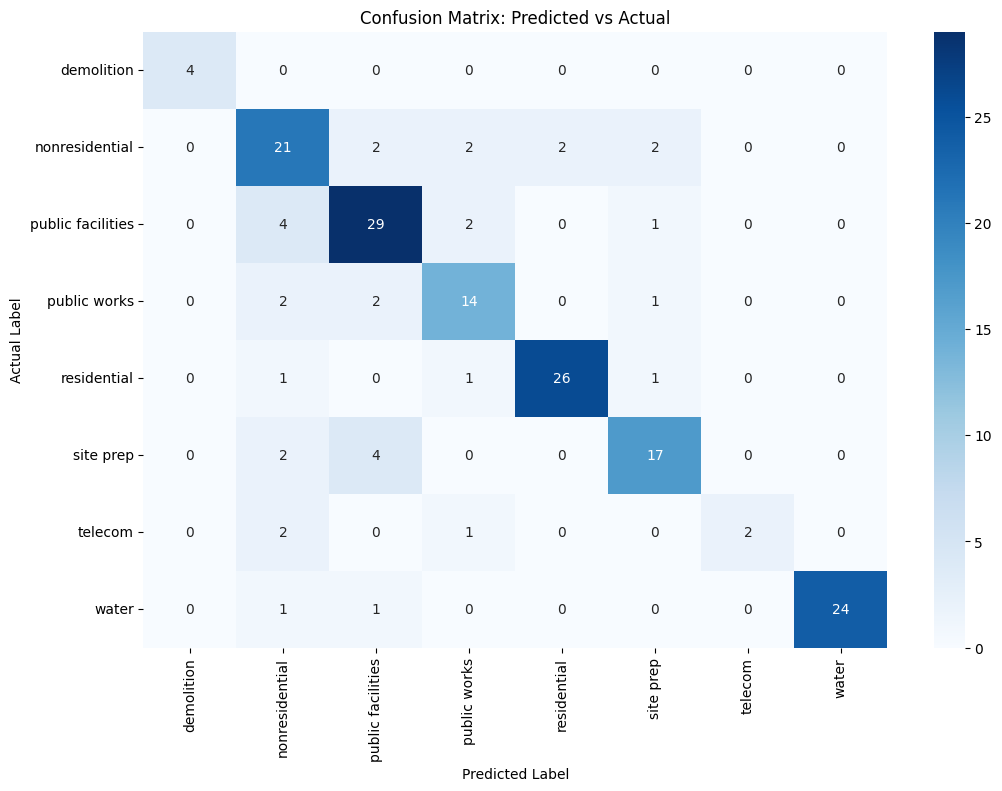

In [110]:

# 4. Print the performance metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize with a Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Cross-Validation

Oh fun, this is humbling. We are essentially capped at 0.71 for this kind of model at this roughness.

In [111]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# sketch out cross-validation strategy
# use 'Stratified' because classes are imbalanced (e.g., Water vs Telecom)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#use 'f1_weighted' since that is the metric we were tracking
cv_scores = cross_val_score(
    model, 
    label_df['Project Name'], 
    label_df['Label'], 
    cv=skf, 
    scoring='f1_weighted'
)

#results
print(f"All CV Scores: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

All CV Scores: [0.69504524 0.70024164 0.74001308 0.72922908 0.72389355]
Mean F1-Score: 0.718
Standard Deviation: 0.017


## Final Data Output

In [112]:
# getting the other half to predict and then assembling together
# label vs category scored, I'm targeting the "other" category

# get unlabelled data
predict_df = det_df[det_df['Label'] == ""].copy()
print("Data yet to be labelled: ", predict_df.shape[0])
# get probabilities of each project name being labelled correctly in the model
probs = model.predict_proba(predict_df['Project Name'].astype(str)) 

predict_df['Confidence'] = np.max(probs, axis=1)

predict_df['Label'] = predict_df['Project Name'].apply(lambda x: hybrid_predict(str(x)))
print(predict_df['Label'].value_counts())

full_df = pd.concat([predict_df, label_df]).sort_index().drop_duplicates()
print("Full df shape: ", full_df['Label'].shape[0])


Data yet to be labelled:  2011
Label
other                580
residential          336
water                293
site prep            220
public facilities    218
public works         190
nonresidential       107
telecom               41
demolition            26
Name: count, dtype: int64
Full df shape:  3000


In [113]:
# adding back in the past project names to go through by hand when needed:
# uses path from the start of script to shpd-plumb.csv
names = pd.read_csv(path)
names = names[['Project Name', 'Project Number']]

full_df = pd.merge(names, full_df, how = "left", on = "Project Number", suffixes=('', '_ugly'))
full_df = full_df.drop(columns = ['Project Name_ugly'])

print(full_df.head())


                                        Project Name Project Number  \
0  DPP Permits for Matthew & Alicia Willis: 2012 ...    2012PR00405   
1  County of Hawaii SMA Use Permit for Constructi...    2013PR04659   
2                              DAGS Nanakuli Library    2014PR14733   
3  Clearinghouse Application No. CL-2015-036 Prin...    2015PR19955   
4  Kokua Kalihi Valley Comprehensive Family Services    2015PR20185   

  Date Opinion 106                      Opinion 106  \
0              NaN                              NaN   
1              NaN                              NaN   
2              NaN                              NaN   
3              NaN                              NaN   
4        7/21/2022  No Historic Properties Affected   

                                 Opinion 106 Comment Date Opinion 6E  \
0                                                NaN       5/12/2021   
1                                                NaN       6/16/2023   
2                         

In [114]:
print("Task finished, writing to CSV in /clean-data")
full_df.to_csv('../clean-data/shpd-labelled.csv')

Task finished, writing to CSV in /clean-data
